# Stock Price Prediction Based on Time Series Data, Using:
## -Deep Learning Method: LSTM
## -Machine Learning Method: 

This is the first project of our team, Infinity Team. We aim to create a project every two - four weeks. To enhance our portfolio, develop our skills, and gain the practical experience of ML and DL. 

Mohammad Alshurbaji, 
Danish Bhatkar

## Setup code
Import some useful packages and increase the default figure size.

In [1]:
import numpy as np
import time
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from scipy.optimize import minimize
from sklearn.metrics import mean_squared_error, mean_absolute_error
from numpy.linalg import svd
import cvxpy as cp
from datetime import datetime
import warnings
import tensorflow as tf
import keras
from keras import layers
import torch
warnings.filterwarnings("ignore")
%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

2025-04-28 15:40:39.369221: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-28 15:40:39.404363: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-28 15:40:39.754287: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-28 15:40:39.889685: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745869239.907240 1506796 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745869239.91

In [2]:
if torch.cuda.is_available():
    print('Good to go!')
else:
    print('Please set GPU via Edit -> Notebook Settings.')

Good to go!


# Load the dataset

In [ ]:
import yfinance as yf

# List of tickers 
tickers = [
    "APP", "MSTR", "PLTR", "NVDA", "AVGO", "MRVL", "ARM", "AAPL",
    "MSFT", "TSLA", "AMZN", "GOOGL", "CRM", "SAP", "IONQ", "RDDT",
    "ALAB", "QUBT", "SEZL", "RDVT"
]
#Downloading the Dataset:
# dataset = yf.download(tickers, start = "2015-12-01", end ="2024-12-01", interval = '1d') ['Adj Close']
dataset = yf.download(tickers, start = "2006-12-01", end ="2024-12-01", interval = '1d') ['Adj Close']
dataset.to_csv("Leading Tech Companies.csv")
dataset.fillna(0)
print(dataset.head())
print(dataset.shape)

In [7]:
# Taking the two disasters into consideration
import yfinance as yf

# List of tickers 
tickers = [
    "NVDA", "AAPL",
    "MSFT", "TSLA", "AMZN", "GOOGL"
]
#Downloading the Dataset:
dataset = yf.download(tickers, start = "2006-12-01", end ="2024-12-01", interval = '1d') ['Adj Close']
dataset.to_csv("Leading Tech Companies.csv")
dataset.fillna(0)
print(dataset.head())
print(dataset.shape)


[*********************100%***********************]  6 of 6 completed

Ticker          AAPL    AMZN      GOOGL       MSFT      NVDA  TSLA
Date                                                              
2006-12-01  2.751169  1.9705  11.988572  20.750565  0.543220   NaN
2006-12-04  2.745143  1.9550  12.089557  20.900215  0.565230   NaN
2006-12-05  2.749663  1.9490  12.143167  20.757690  0.559422   NaN
2006-12-06  2.706280  1.9450  12.185805  20.657927  0.558658   NaN
2006-12-07  2.622227  1.9060  12.034452  20.558165  0.545207   NaN
(4529, 6)


# Data preprocessing

In [17]:
# List of tickers 
# Use one ticker for simplicity (e.g., 'AAPL')
selected_ticker = "AAPL"
data = dataset[selected_ticker].values.reshape(-1, 1)

# Scale the data to the range [0, 1]
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# Create time-series sequences data (X, y pairs)
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i + sequence_length])
        y.append(data[i + sequence_length])
    return np.array(X), np.array(y)

sequence_length = 60
X, y = create_sequences(scaled_data, sequence_length)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

In [8]:
# List of tickers 
# Use one ticker for simplicity (e.g., 'AAPL')
selected_ticker = "AAPL"
data = dataset[selected_ticker].values.reshape(-1, 1)

# Scale the data to the range [0, 1]
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# Create time-series sequences data (X, y pairs)
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i + sequence_length])
        y.append(data[i + sequence_length])
    return np.array(X), np.array(y)

sequence_length = 90
X, y = create_sequences(scaled_data, sequence_length)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

print(f"The shape of X_train is {len(X_train)}, and the shape of X_test is {len(X_test)}, and the shape of y_train is {len(y_train)}, and y_test is {len(y_test)}")

num_test_samples = len(X_test)
test_dates = dataset.index[-num_test_samples:]  # Get last 20% of dataset dates
print(test_dates)

The shape of X_train is 3551, and the shape of X_test is 888, and the shape of y_train is 3551, and y_test is 888
DatetimeIndex(['2021-05-21', '2021-05-24', '2021-05-25', '2021-05-26',
               '2021-05-27', '2021-05-28', '2021-06-01', '2021-06-02',
               '2021-06-03', '2021-06-04',
               ...
               '2024-11-15', '2024-11-18', '2024-11-19', '2024-11-20',
               '2024-11-21', '2024-11-22', '2024-11-25', '2024-11-26',
               '2024-11-27', '2024-11-29'],
              dtype='datetime64[ns]', name='Date', length=888, freq=None)


In [16]:
# To get familiarity of what yfinance can give us in terms of the stock info:
dat = yf.Ticker("MSFT")
dat.info
dat.calendar
dat.analyst_price_targets
dat.quarterly_income_stmt
dat.history(period='1mo')
dat.option_chain(dat.options[0]).calls

,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency
0,MSFT250131C00230000,2025-01-17 17:21:53+00:00,230.0,200.63,0.0,0.0,0.0,0.0,NaN,1,0.000010,True,REGULAR,USD
1,MSFT250131C00240000,2025-01-16 19:40:34+00:00,240.0,187.80,0.0,0.0,0.0,0.0,1.0,2,0.000010,True,REGULAR,USD
2,MSFT250131C00250000,2025-01-24 15:10:01+00:00,250.0,194.83,0.0,0.0,0.0,0.0,3.0,3,0.000010,True,REGULAR,USD
3,MSFT250131C00260000,2025-01-24 20:32:32+00:00,260.0,182.88,0.0,0.0,0.0,0.0,1.0,1,0.000010,True,REGULAR,USD
4,MSFT250131C00270000,2025-01-16 16:52:24+00:00,270.0,157.30,0.0,0.0,0.0,0.0,NaN,13,0.000010,True,REGULAR,USD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77,MSFT250131C00530000,2025-01-28 20:46:03+00:00,530.0,0.03,0.0,0.0,0.0,0.0,122.0,173,0.500005,False,REGULAR,USD
78,MSFT250131C00535000,2025-01-28 19:56:11+00:00,535.0,0.03,0.0,0.0,0.0,0.0,79.0,232,0.500005,False,REGULAR,USD
79,MSFT250131C00540000,2025-01-28 20:16:07+00:00,540.0,0.01,0.0,0.0,0.0,0.0,3.0,54,0.500005,False,REGULAR,USD
80,MSFT250131C00550000,2025-01-28 17:39:00+00:00,550.0,0.01,0.0,0.0,0.0,0.0,1.0,29,0.500005,False,REGULAR,USD


# Visualization

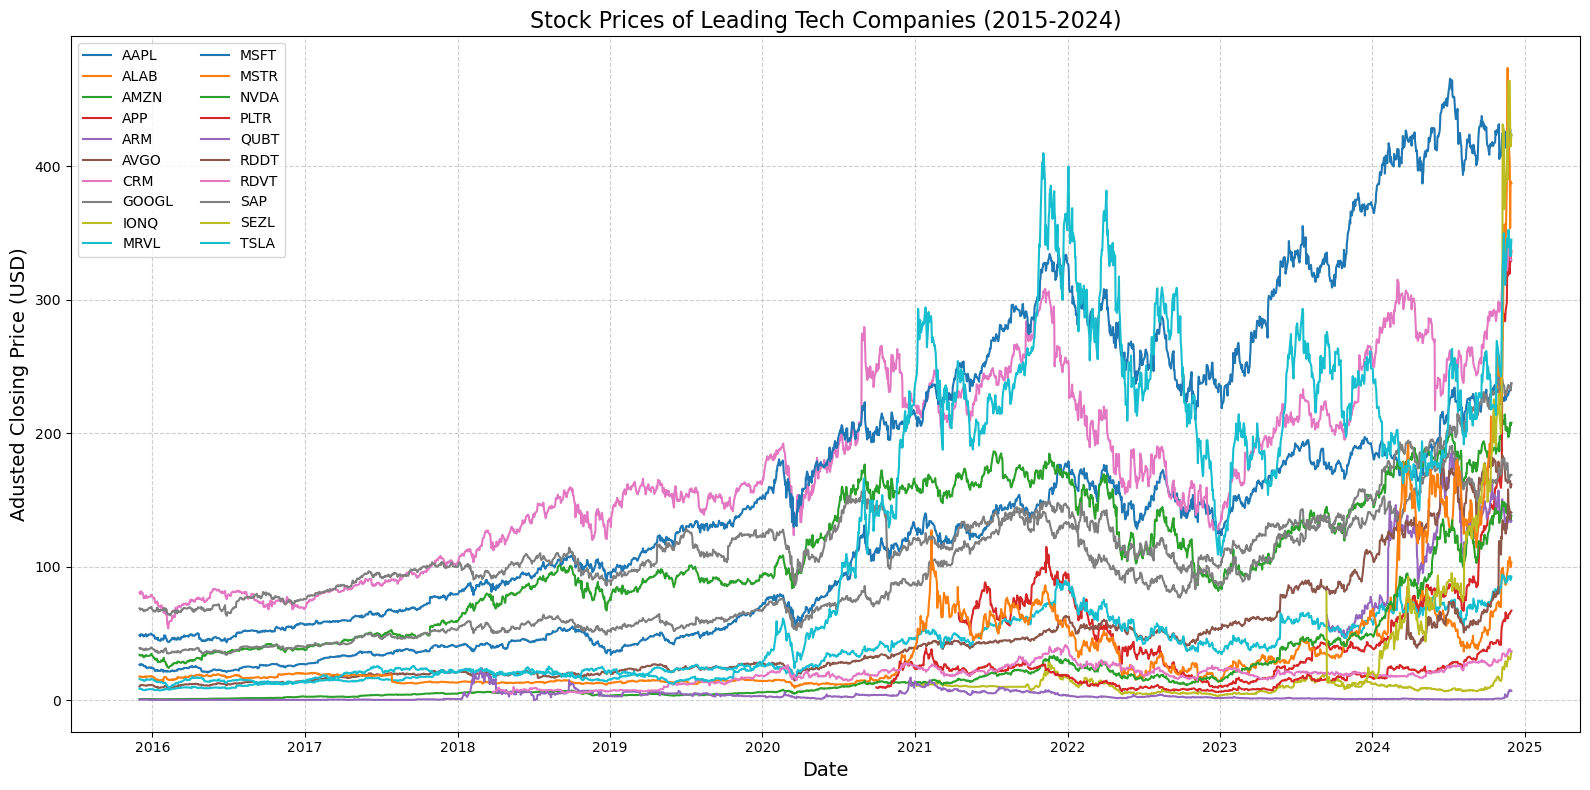

In [5]:
plt.figure(figsize =(16,8))
for ticker in dataset.columns:
    plt.plot(dataset.index, dataset[ticker], label=ticker)
plt.title("Stock Prices of Leading Tech Companies (2015-2024)", fontsize=16)
plt.xlabel("Date", fontsize = 14)
plt.ylabel("Adusted Closing Price (USD)", fontsize=14)
plt.legend(loc="upper left", fontsize=10, ncol=2)
plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

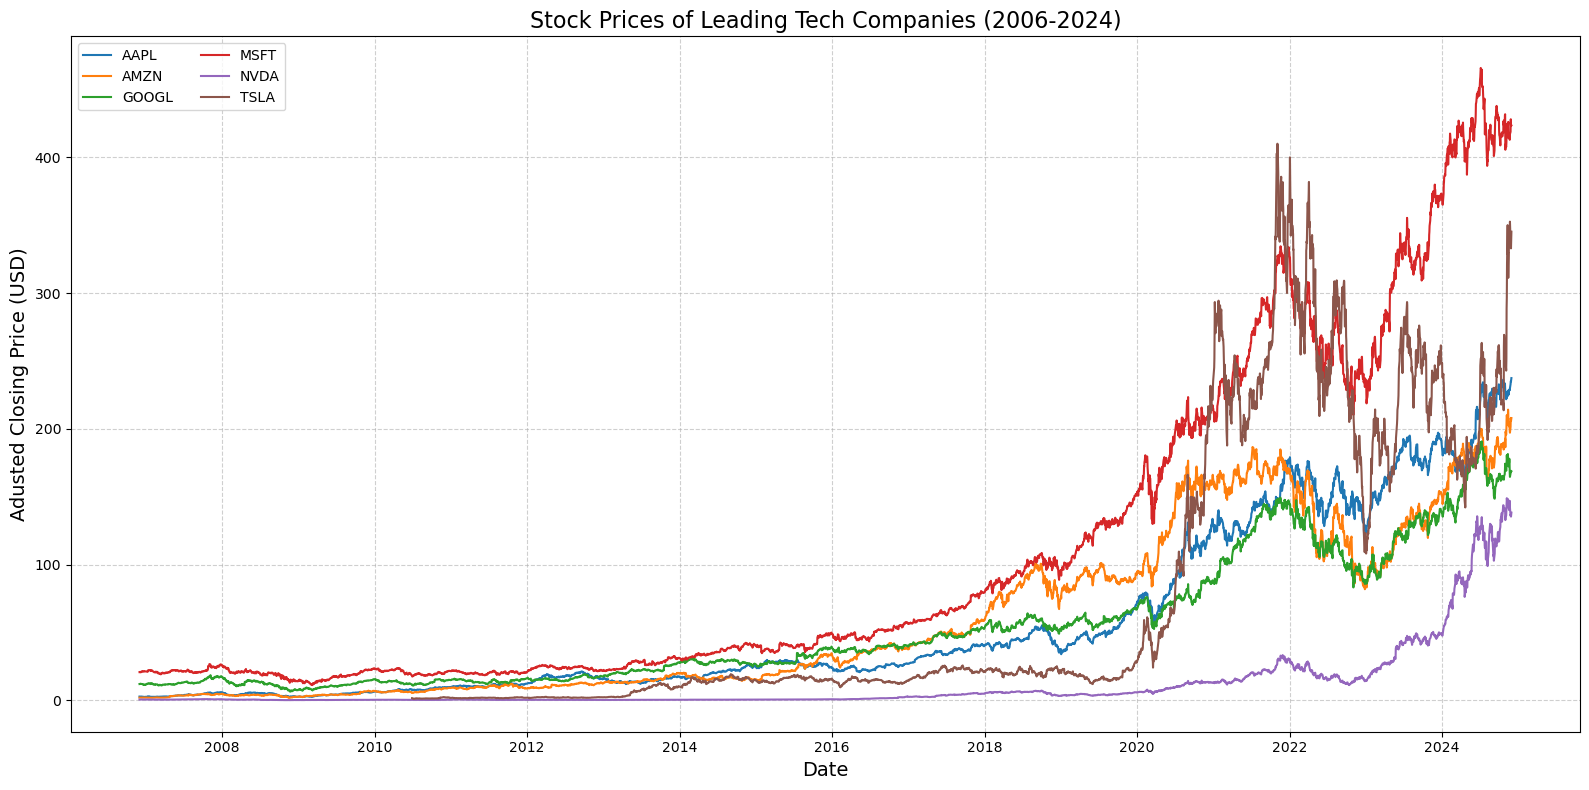

In [9]:
plt.figure(figsize =(16,8))
for ticker in dataset.columns:
    plt.plot(dataset.index, dataset[ticker], label=ticker)
plt.title("Stock Prices of Leading Tech Companies (2006-2024)", fontsize=16)
plt.xlabel("Date", fontsize = 14)
plt.ylabel("Adusted Closing Price (USD)", fontsize=14)
plt.legend(loc="upper left", fontsize=10, ncol=2)
plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

# Preprocessing

# Define the Deep Learning model

Long Short Term Memory (LSTM) has been chosen for our project since it has so many related features to our proplem.

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from sklearn.preprocessing import MinMaxScaler

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    Dropout(0.2),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(25, activation='relu'),
    Dense(1) #The output
])

# Define the Machine Learning model


## Model Initialization
Note: This section initializes the model, loss function , and optimizer.

In [19]:
model.compile(optimizer='adam', loss='mean_squared_error')

## Training Loop
Note: This section contains the training loop. It iterates over the specified number of epochs and trains the model on the training set. During the validation phase, it evaluates the model on the validation set without performing backpropagation and optimization. The loss for each epoch is calculated and printed.

In [12]:
# Train the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32,
    verbose=2
)
# Predict and reverse the scaling
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)

Epoch 1/20
111/111 - 6s - 54ms/step - loss: 8.2787e-04 - val_loss: 0.0035
Epoch 2/20
111/111 - 4s - 35ms/step - loss: 2.7786e-04 - val_loss: 8.2075e-04
Epoch 3/20
111/111 - 4s - 34ms/step - loss: 2.3172e-04 - val_loss: 6.3145e-04
Epoch 4/20
111/111 - 4s - 34ms/step - loss: 2.0475e-04 - val_loss: 6.9313e-04
Epoch 5/20
111/111 - 4s - 35ms/step - loss: 2.0390e-04 - val_loss: 0.0046
Epoch 6/20
111/111 - 4s - 35ms/step - loss: 2.2625e-04 - val_loss: 0.0021
Epoch 7/20
111/111 - 4s - 35ms/step - loss: 1.8661e-04 - val_loss: 0.0026
Epoch 8/20
111/111 - 4s - 35ms/step - loss: 1.7753e-04 - val_loss: 6.1415e-04
Epoch 9/20
111/111 - 4s - 35ms/step - loss: 1.6668e-04 - val_loss: 8.1570e-04
Epoch 10/20
111/111 - 4s - 35ms/step - loss: 1.4818e-04 - val_loss: 0.0011
Epoch 11/20
111/111 - 4s - 35ms/step - loss: 1.3857e-04 - val_loss: 0.0017
Epoch 12/20
111/111 - 4s - 35ms/step - loss: 1.5434e-04 - val_loss: 0.0015
Epoch 13/20
111/111 - 4s - 35ms/step - loss: 1.3694e-04 - val_loss: 8.5781e-04
Epoch 14/2

## Loss Functions


In [21]:

# Evaluate the model
loss = model.evaluate(X_test, y_test)
print(f"Test Loss: {loss}")

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0011    
Test Loss: 0.00198058458045125


## Visualize the Training Curve and Validation Results
Note: In this section, you need to visualize the Training curve in the training loop and print out the first 10 validation data in the order of: input image- prediction - groundtruth 

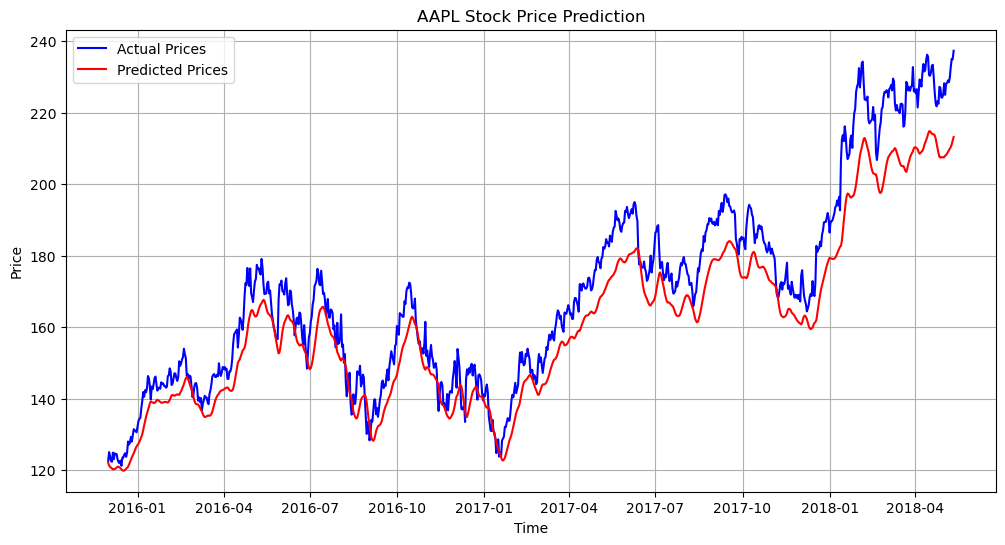

In [22]:
# Plot the results
import matplotlib.pyplot as plt

y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))
dates = pd.date_range(start="2015-12-01", periods=len(y_test_actual), freq='D')
plt.figure(figsize=(12, 6))
plt.plot(dates, y_test_actual, label="Actual Prices", color='blue')
plt.plot(dates, predictions, label="Predicted Prices", color='red')
plt.title(f"{selected_ticker} Stock Price Prediction")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.grid()
plt.show()

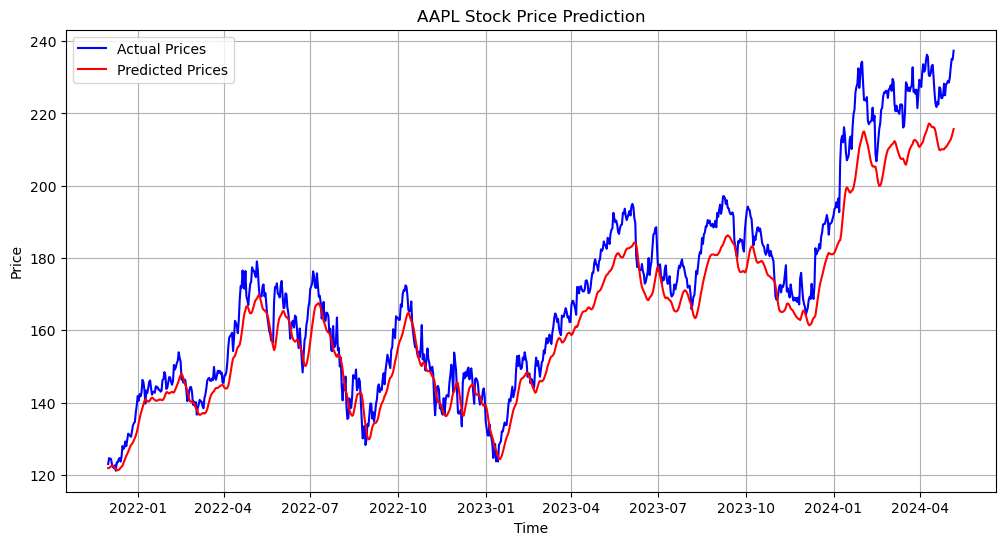

In [14]:
# Plot the results
import matplotlib.pyplot as plt

y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))
dates = pd.date_range(start="2021-12-01", periods=len(y_test_actual), freq='D')
plt.figure(figsize=(12, 6))
plt.plot(dates, y_test_actual, label="Actual Prices", color='blue')
plt.plot(dates, predictions, label="Predicted Prices", color='red')
plt.title(f"{selected_ticker} Stock Price Prediction")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.grid()
plt.show()

# Processing all the stocks

# My thinking approach:
In order to process all the stocks, I had to train the model on diverse stocks so it has a good understanding of processing all the stocks and make a good prediction. Otherwise, a mismatched predictions will occurs since the model studied the pattern on one stock only. 

In [11]:
# Combine the data from diverse stocks:
diverse_tickers = ['AAPL', 'MSFT', 'NVDA', 'AMZN', 'TSLA']
combined_data = []
for ticker in diverse_tickers:
    ticker_data = dataset[ticker].values.reshape(-1,1)
    combined_data.append(ticker_data)
    
# Concatenation
combined_data = np.concatenate(combined_data, axis = 0)
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data=scaler.fit_transform(combined_data)

#Sequences
sequence_length = 60
X_train, y_train = create_sequences(scaled_data, sequence_length)
print(X_train.shape)
# print(scaled_data.shape)
# print(X_train.shape[1])
# print(X_train[0])

(11265, 60, 1)


In [19]:
# Combine the data from diverse stocks:
diverse_tickers = ['AAPL', 'MSFT', 'NVDA', 'AMZN', 'TSLA']
combined_data = []
for ticker in diverse_tickers:
    ticker_data = dataset[ticker].values.reshape(-1,1)
    combined_data.append(ticker_data)
    
# Concatenation
combined_data = np.concatenate(combined_data, axis = 0)
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data=scaler.fit_transform(combined_data)

#Sequences
sequence_length = 90
X_train, y_train = create_sequences(scaled_data, sequence_length)
print(X_train.shape)
print(len(X_train),len(y_train))

(22555, 90, 1)
22555 22555


In [23]:
#Training
model.fit(X_train, y_train, epochs = 30, batch_size=32, validation_split=0.2)

Epoch 1/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 3.0316e-05 - val_loss: 1.5783e-04
Epoch 2/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 2.7347e-05 - val_loss: 1.4257e-04
Epoch 3/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 2.4385e-05 - val_loss: 1.6565e-04
Epoch 4/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 2.2353e-05 - val_loss: 1.9284e-04
Epoch 5/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 2.0974e-05 - val_loss: 2.5458e-04
Epoch 6/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 1.8308e-05 - val_loss: 4.0163e-04
Epoch 7/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 1.8931e-05 - val_loss: 3.1736e-04
Epoch 8/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 1.6342e-05 - val_loss: 2.8887e-04
Epoch 9/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 1.6443e-05 - val_loss: 4.1860e-04
Epoch 10/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 1.4637e-05 - val_loss: 3.5205e-04
Epoch 11/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 1.8445e-0

In [12]:
#Training
model.fit(X_train, y_train, epochs = 30, batch_size=32, validation_split=0.2)

Epoch 1/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 6.3231e-04 - val_loss: 5.3234e-04
Epoch 2/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 6.6246e-04 - val_loss: 4.4324e-04
Epoch 3/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 6.6299e-04 - val_loss: 5.1932e-04
Epoch 4/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 6.4021e-04 - val_loss: 3.6710e-04
Epoch 5/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 7.9069e-04 - val_loss: 4.0880e-04
Epoch 6/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 4.5765e-04 - val_loss: 3.2746e-04
Epoch 7/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 3.7902e-04 - val_loss: 2.9808e-04
Epoch 8/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 4.9096e-04 - val_loss: 2.7077e-04
Epoch 9/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 4.1290e-04 - val_loss: 4.5001e-04
Epoch 10/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 3.8679e-04 - val_loss: 6.1791e-04
Epoch 11/30
282/282 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/

In [15]:

# Evaluate the model
loss = model.evaluate(X_test, y_test)
print(f"Test Loss: {loss}")

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.5841e-04
Test Loss: 0.00020252329704817384


# Fine Tuning
Fine Tuning to fast up and get more accurate results, by tuning the weights on each stock:

In [25]:
# Fine-tuning for each stock
for ticker in tickers:
    print(f"Fine-tuning for {ticker}...")
    
    # Extract and scale the specific stock's data
    ticker_data = dataset[ticker].values.reshape(-1, 1)
    scaled_ticker_data = scaler.fit_transform(ticker_data)
    
    # Create sequences for fine-tuning
    X_ticker, y_ticker = create_sequences(scaled_ticker_data, sequence_length)
    
    # Fine-tune the model for the current stock
    model.fit(X_ticker, y_ticker, epochs=10, batch_size=32)


Fine-tuning for APP...
Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: nan
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: nan
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: nan
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: nan
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: nan
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: nan
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: nan
Epoch 8/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: nan
Epoch 9/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: nan
Epoch 10/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: nan
Fine-tuning for MSTR...
Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: nan
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: nan
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: nan
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: nan
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s

In [47]:
# Fine-tuning for each stock
for ticker in tickers:
    print(f"Fine-tuning for {ticker}...")
    
    # Extract and scale the specific stock's data
    ticker_data = dataset[ticker].values.reshape(-1, 1)
    scaled_ticker_data = scaler.fit_transform(ticker_data)
    
    # Create sequences for fine-tuning
    X_ticker, y_ticker = create_sequences(scaled_ticker_data, sequence_length)
    
    # Fine-tune the model for the current stock
    model.fit(X_ticker, y_ticker, epochs=10, batch_size=32)


Fine-tuning for NVDA...
Epoch 1/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: nan
Epoch 2/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: nan
Epoch 3/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: nan
Epoch 4/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: nan
Epoch 5/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: nan
Epoch 6/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: nan
Epoch 7/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: nan
Epoch 8/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: nan
Epoch 9/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: nan
Epoch 10/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: nan
Fine-tuning for ARM...
Epoch 1/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: nan
Epoch 2/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: nan
Epoch 3/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: nan
Epoch 4/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: nan
Epoch 5/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 3s

# Prediction Process to see if the model working well:

In [26]:
# Step 1: Prepare the data for prediction (inference)
ticker = 'AAPL'  # Example for AAPL, you can loop through other tickers as needed

# Extract and scale the specific stock's data
ticker_data = dataset[ticker].values.reshape(-1, 1)  # Reshape to be 2D
scaled_ticker_data = scaler.transform(ticker_data)  # Scale using the same scaler

# Generate sequences for the predictions (use the same sequence length as before)
X_inference, _ = create_sequences(scaled_ticker_data, sequence_length)

# Step 2: Make predictions using the fine-tuned model
predictions = model.predict(X_inference)

# Step 3: Inverse scale the predictions to get the actual stock prices
predicted_prices = scaler.inverse_transform(predictions)

# Store predictions
all_predictions = {}
all_predictions[ticker] = predicted_prices
print(f"Size of dictionary: {len(all_predictions)}")
print(all_predictions)

140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
Size of dictionary: 1
{'AAPL': array([[nan],
       [nan],
       [nan],
       ...,
       [nan],
       [nan],
       [nan]], dtype=float32)}


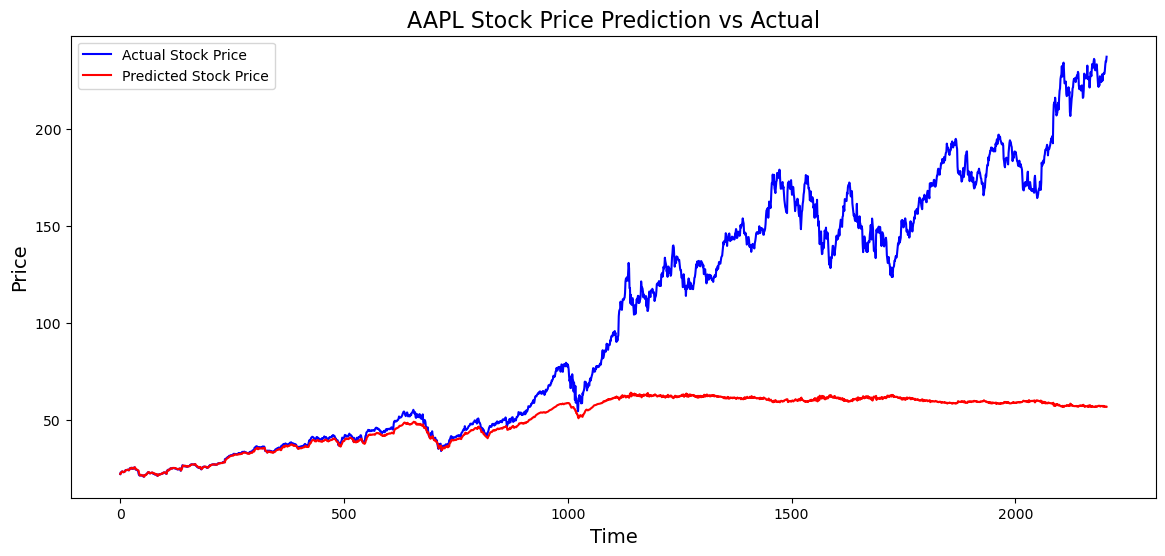

In [54]:
import matplotlib.pyplot as plt

# Step 1: Extract actual stock prices for comparison (for visualization)
actual_prices = ticker_data[sequence_length:]  # Actual prices excluding the first 'sequence_length' values

# Step 2: Visualize the actual vs predicted stock prices
plt.figure(figsize=(14, 6))

# Plot the actual prices
plt.plot(actual_prices, color='blue', label='Actual Stock Price')

# Plot the predicted prices
plt.plot(predicted_prices, color='red', label='Predicted Stock Price')

# Add labels and title
plt.title(f'{ticker} Stock Price Prediction vs Actual', fontsize=16)
plt.xlabel('Time', fontsize=14)
plt.ylabel('Price', fontsize=14)

# Show legend
plt.legend()

# Display the plot
plt.show()


In [28]:
all_predictions = {}

for ticker in tickers:  # Example for AAPL, you can loop through other tickers as needed
    
    # Extract and scale the specific stock's data
    ticker_data = dataset[ticker].values.reshape(-1, 1)  # Reshape to be 2D
    scaled_ticker_data = scaler.transform(ticker_data)  # Scale using the same scaler

    # Generate sequences for the predictions (use the same sequence length as before)
    X_inference, _ = create_sequences(scaled_ticker_data, sequence_length)

    # Step 2: Make predictions using the fine-tuned model
    predictions = model.predict(X_inference)

    # Step 3: Inverse scale the predictions to get the actual stock prices
    predicted_prices = scaler.inverse_transform(predictions)

    # Store predictions
    
    all_predictions[ticker] = predicted_prices
print(f"Size of dictionary: {len(all_predictions)}")
print(all_predictions)

140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
Size of dictionary: 20
{'APP': array([[nan],
       [nan],
       [nan],
       ...,
       [nan],
       [nan],
       [nan]], dtype=float32), 'MSTR': array([[nan],
       [nan],


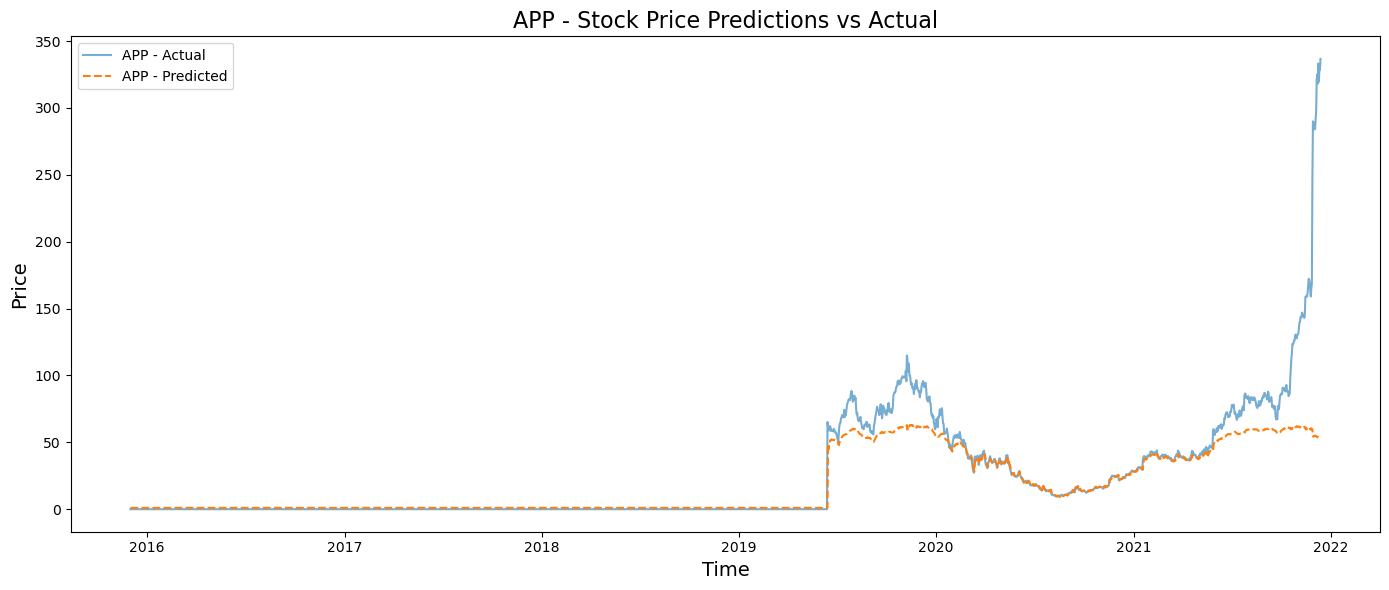

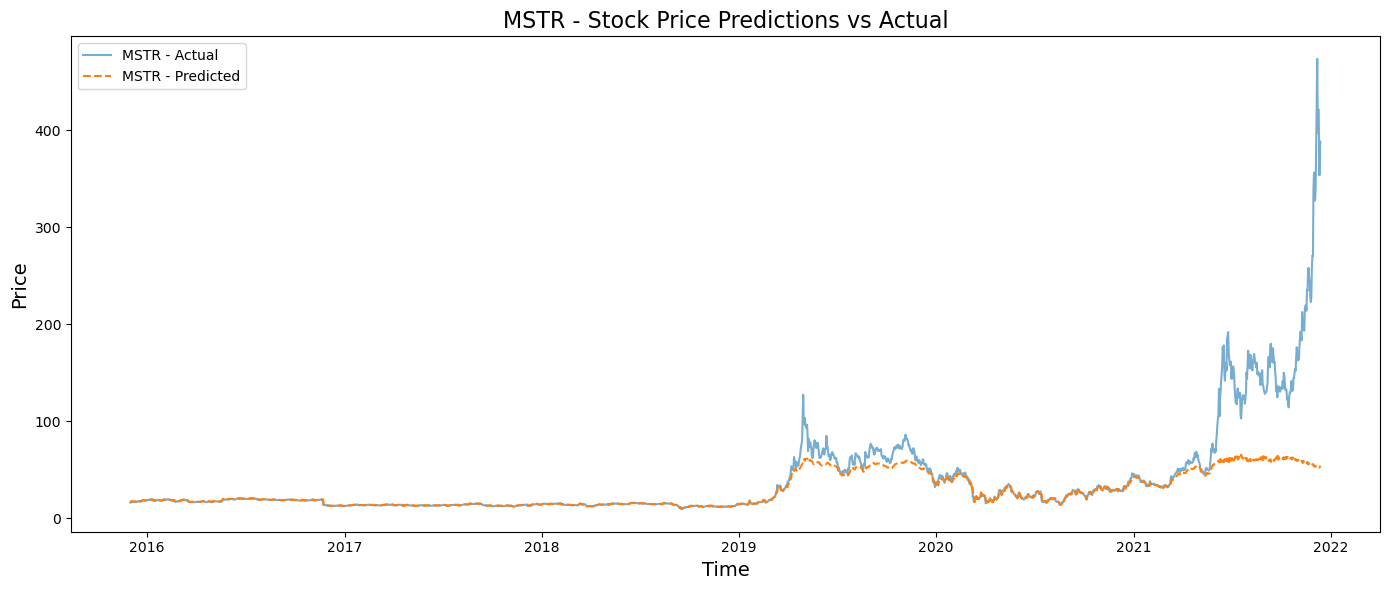

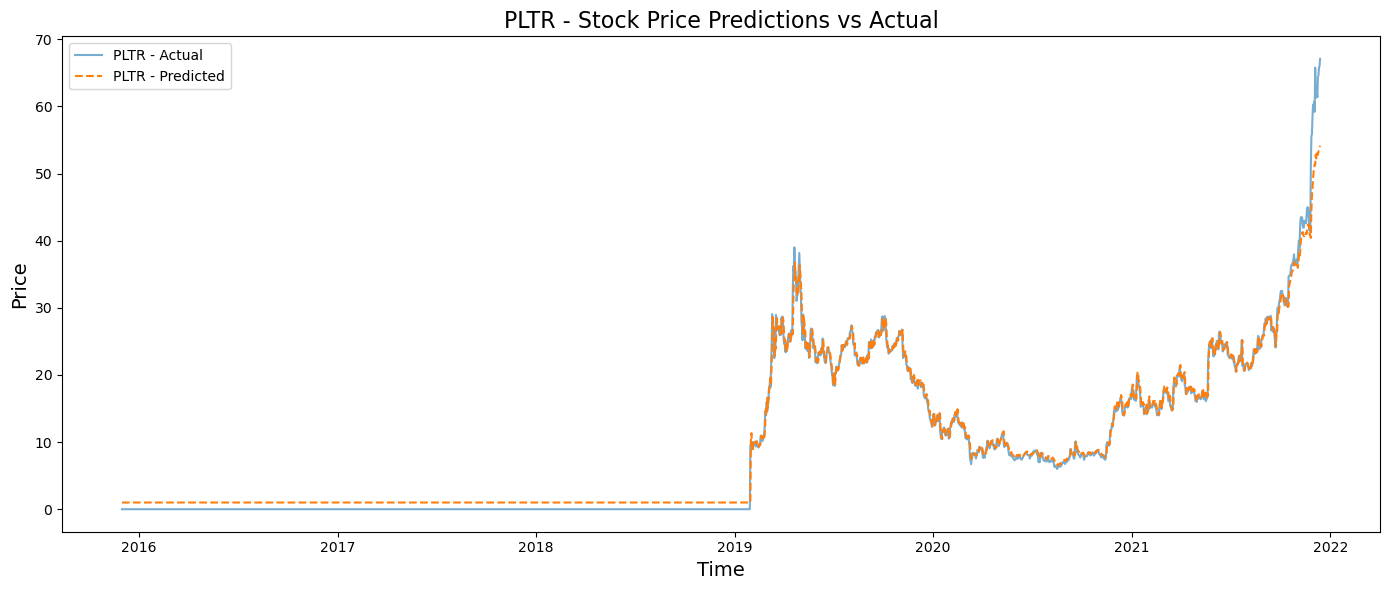

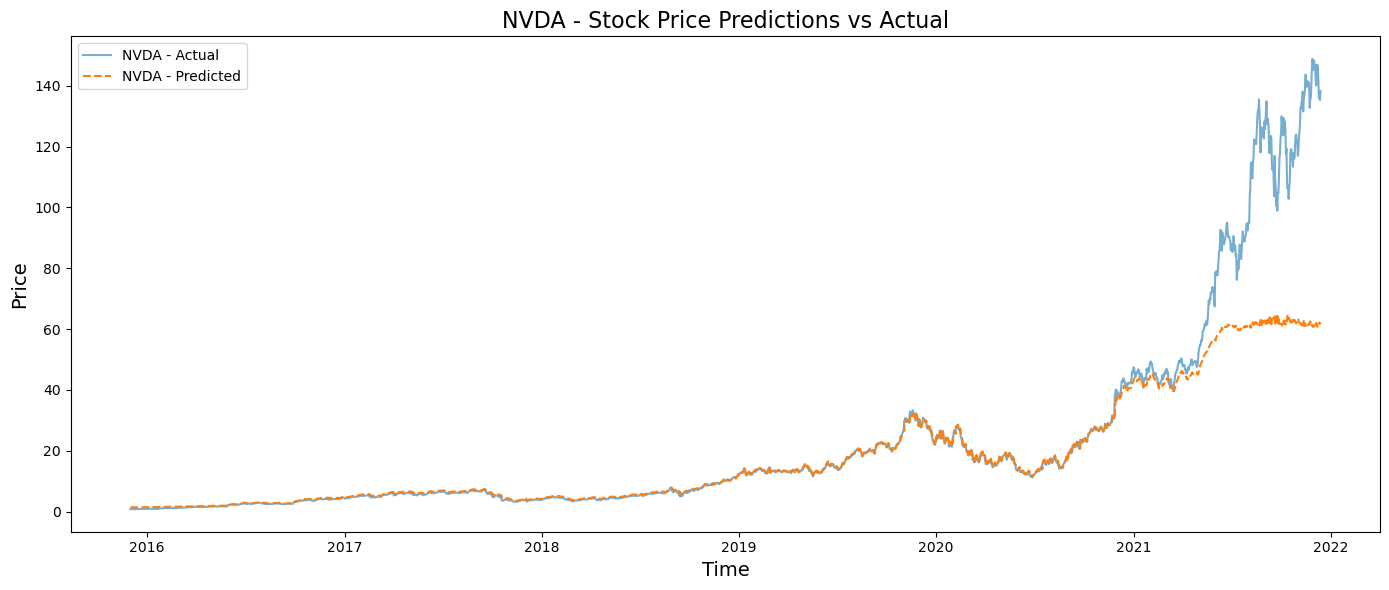

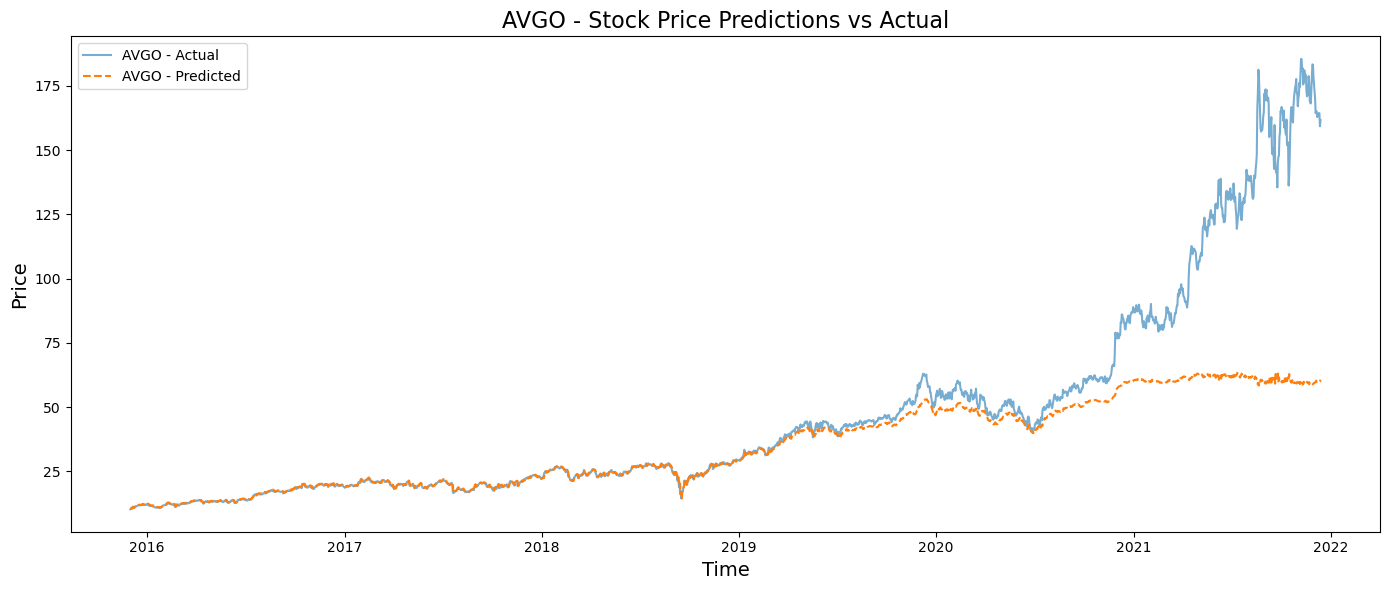

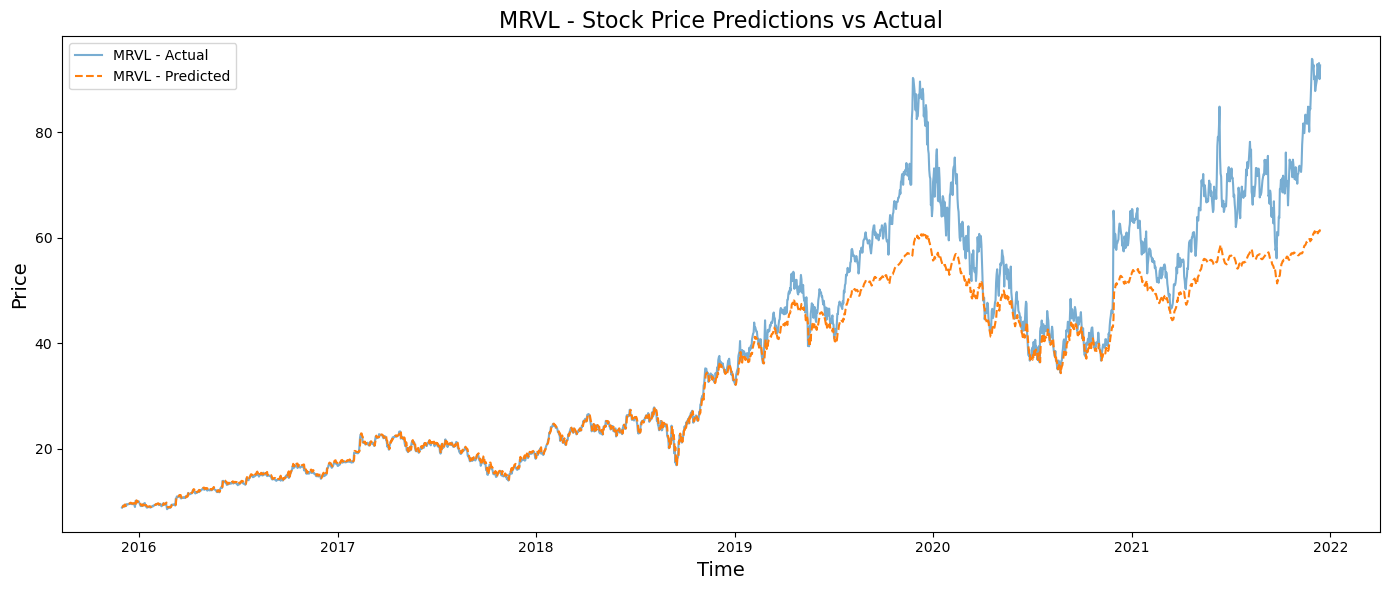

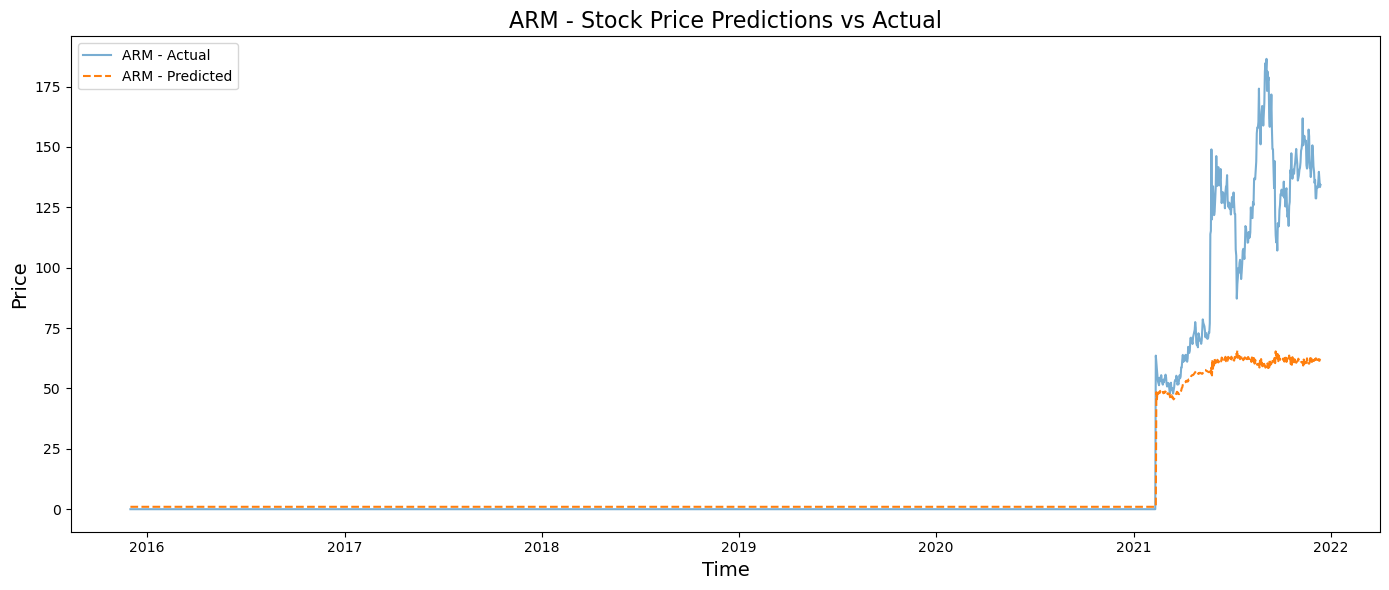

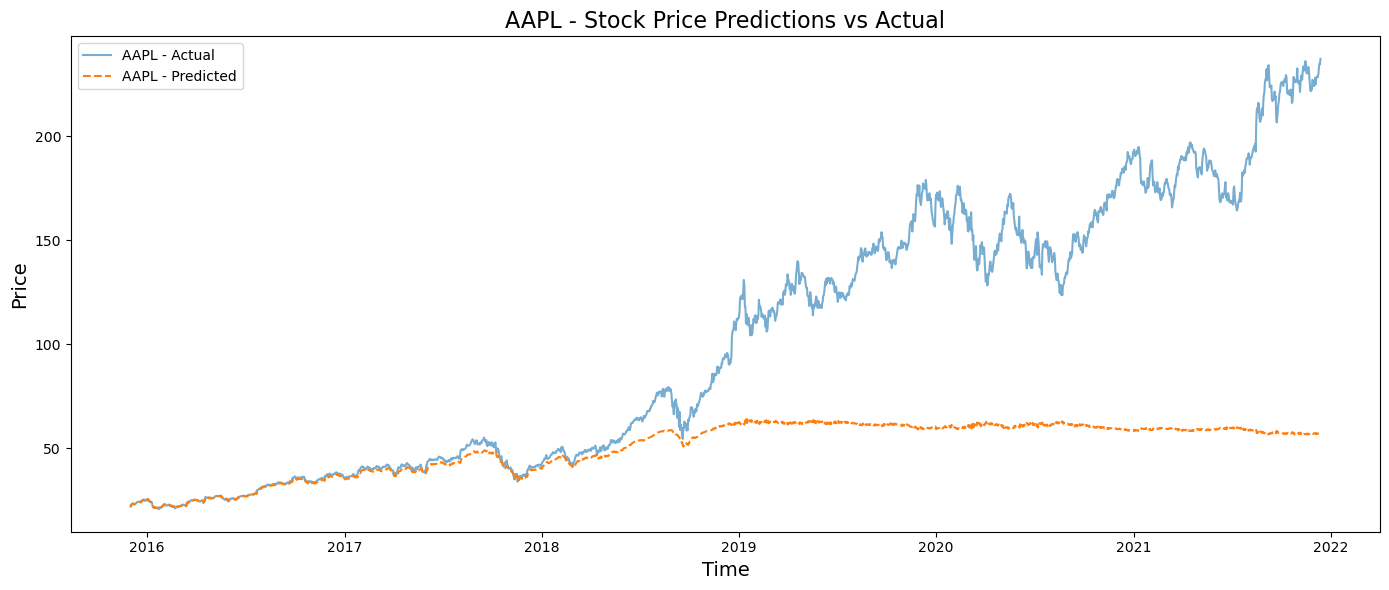

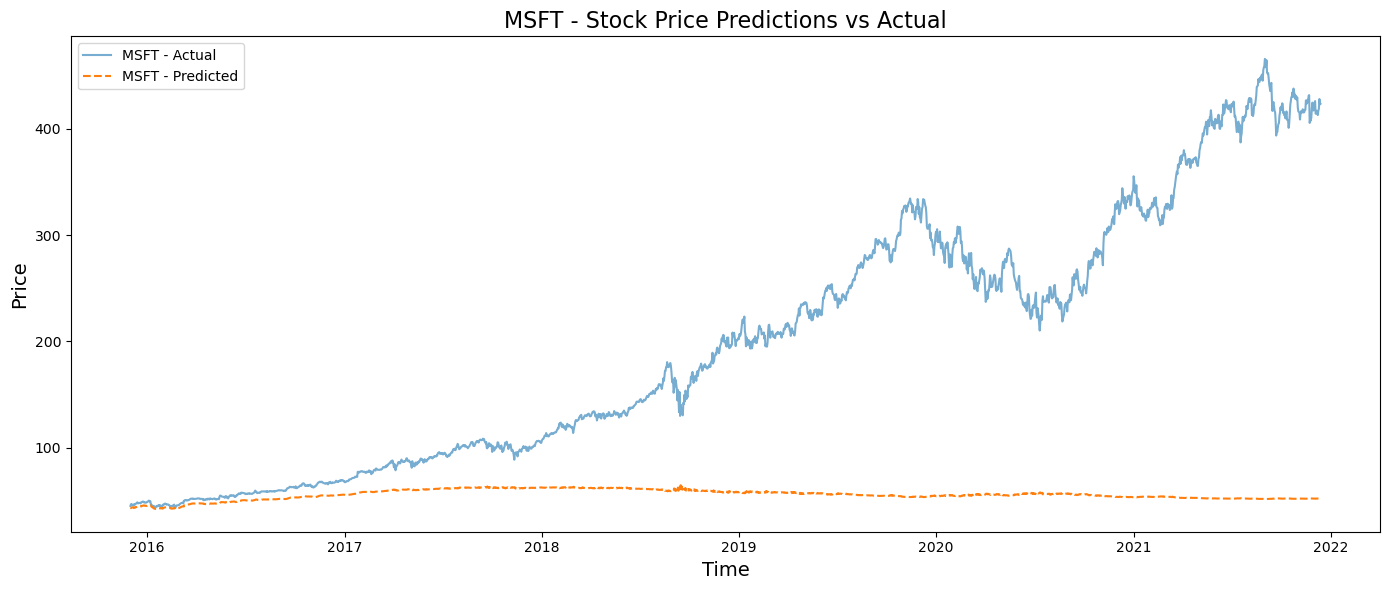

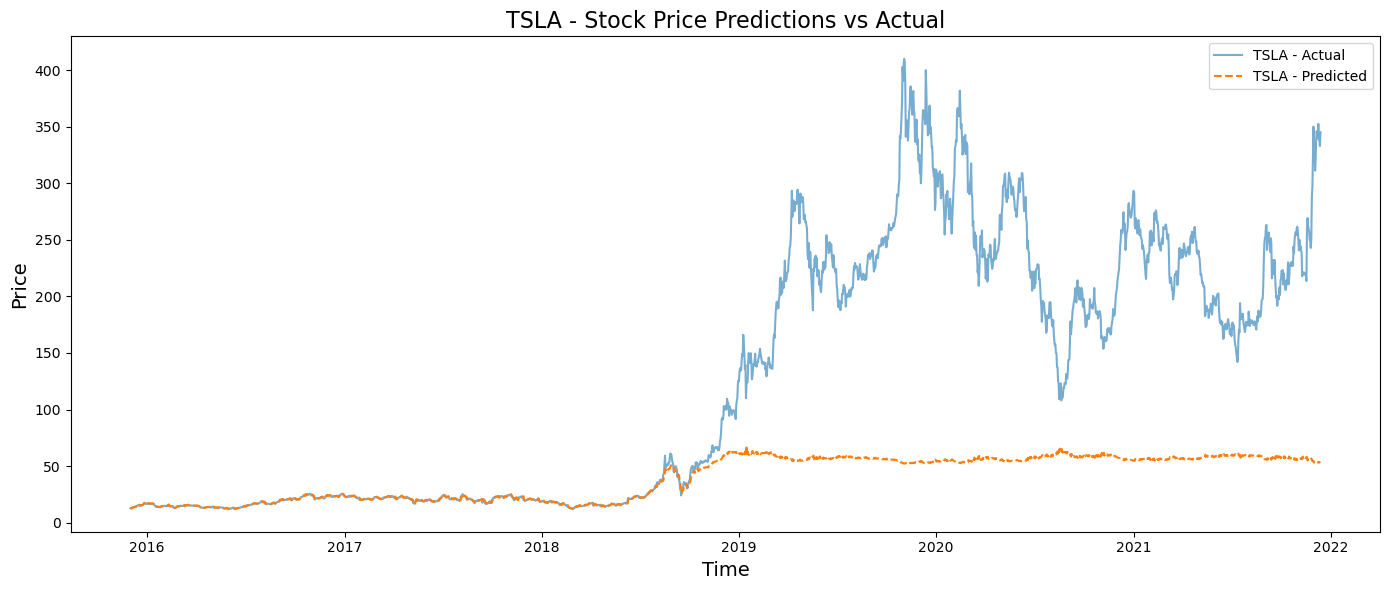

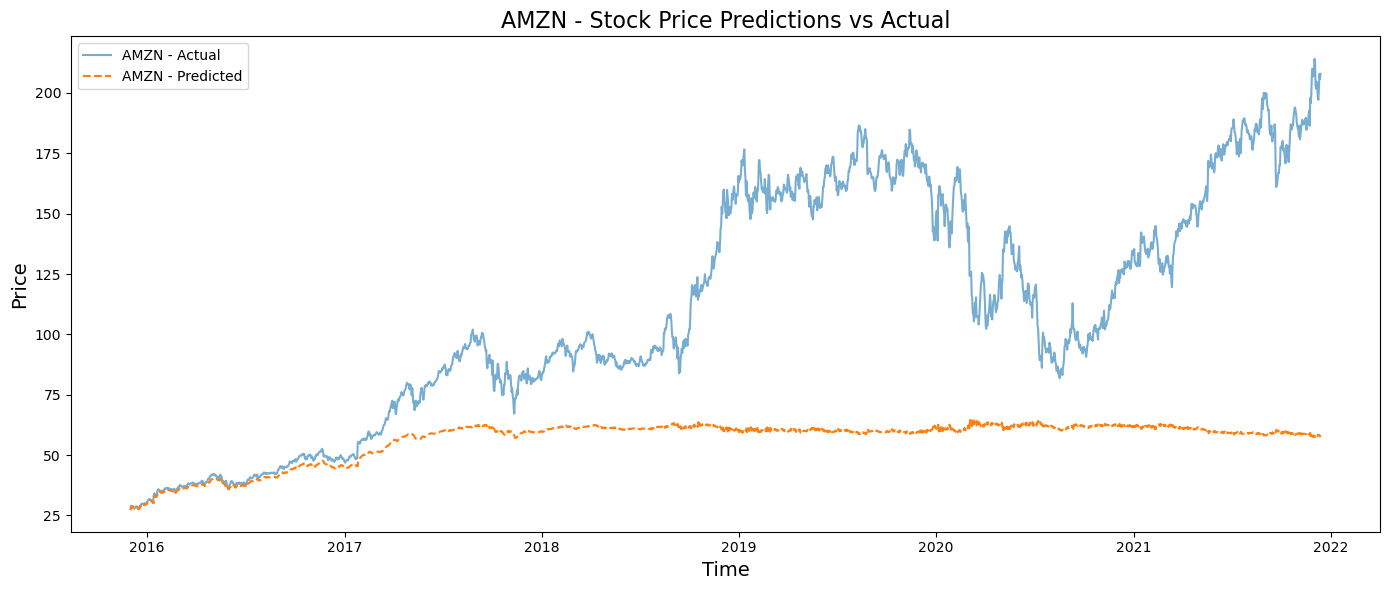

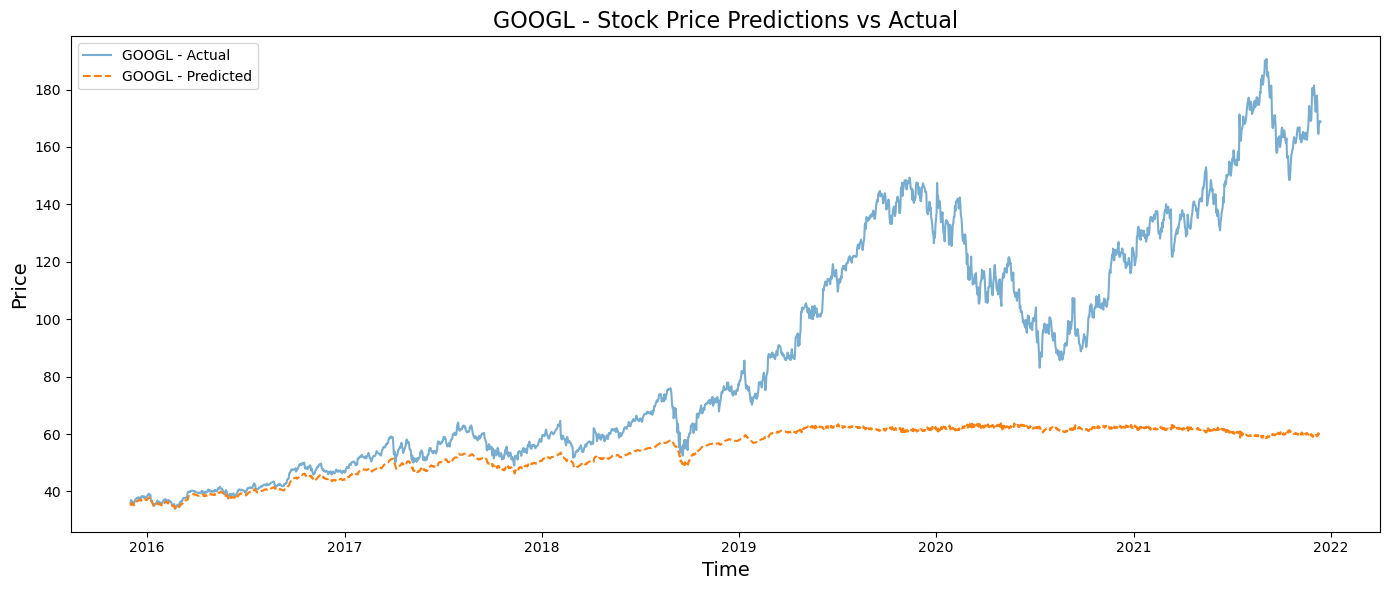

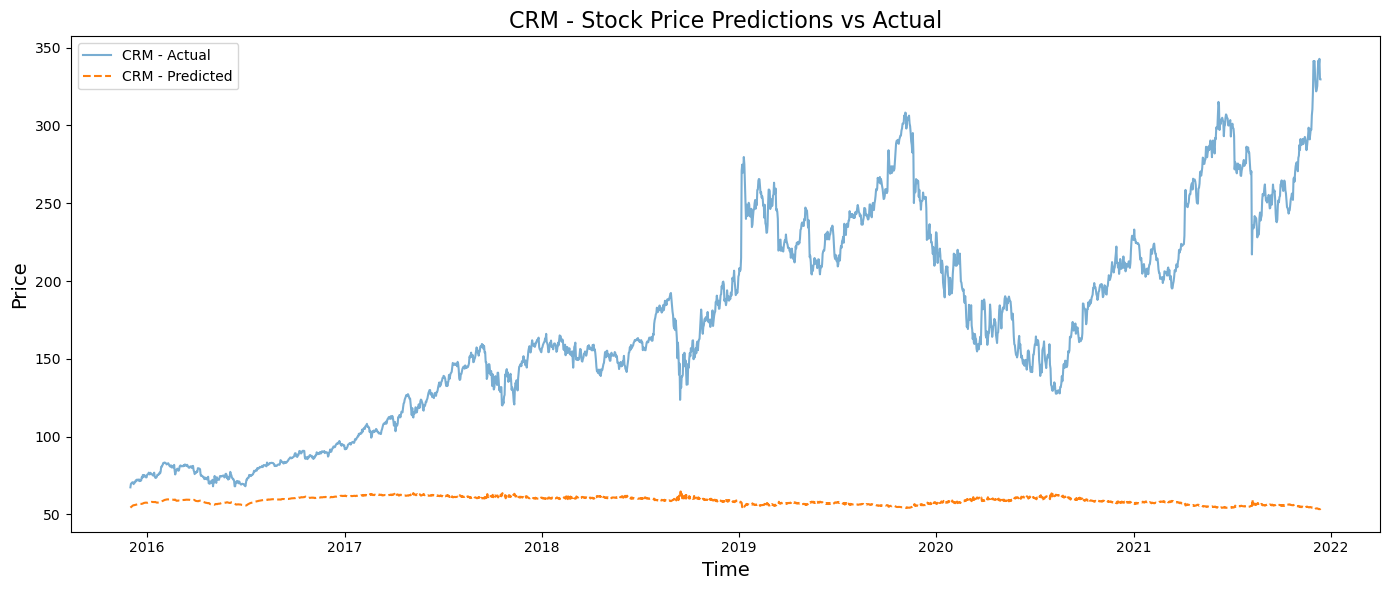

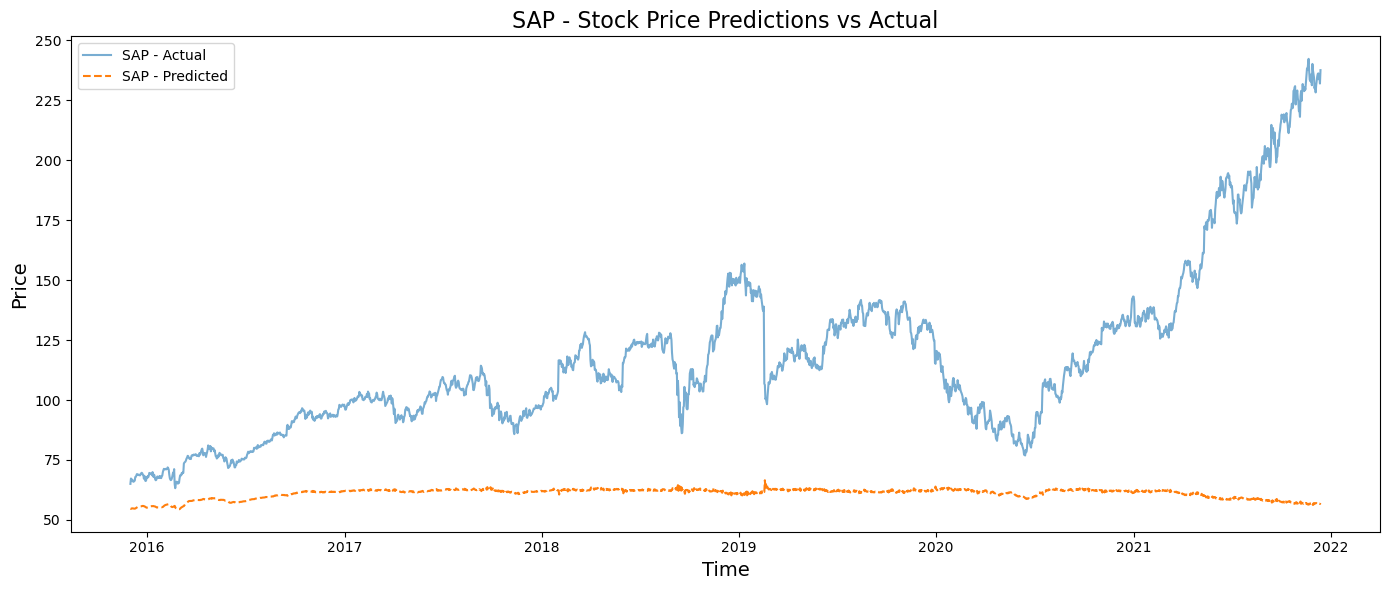

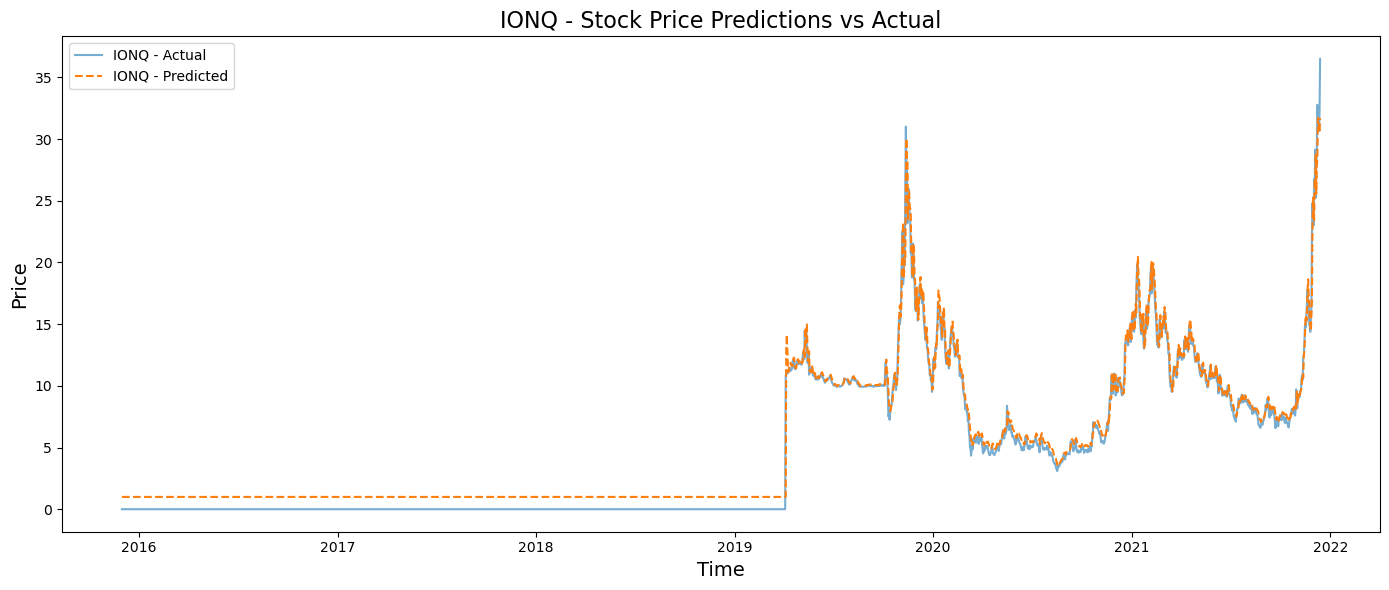

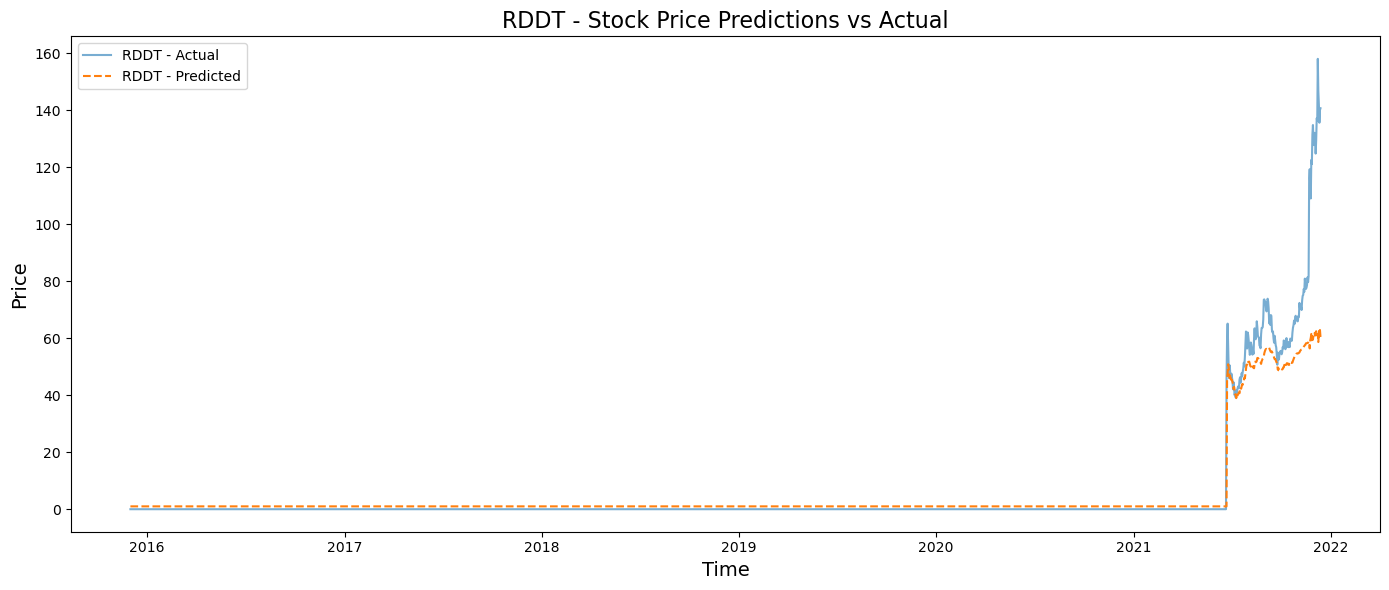

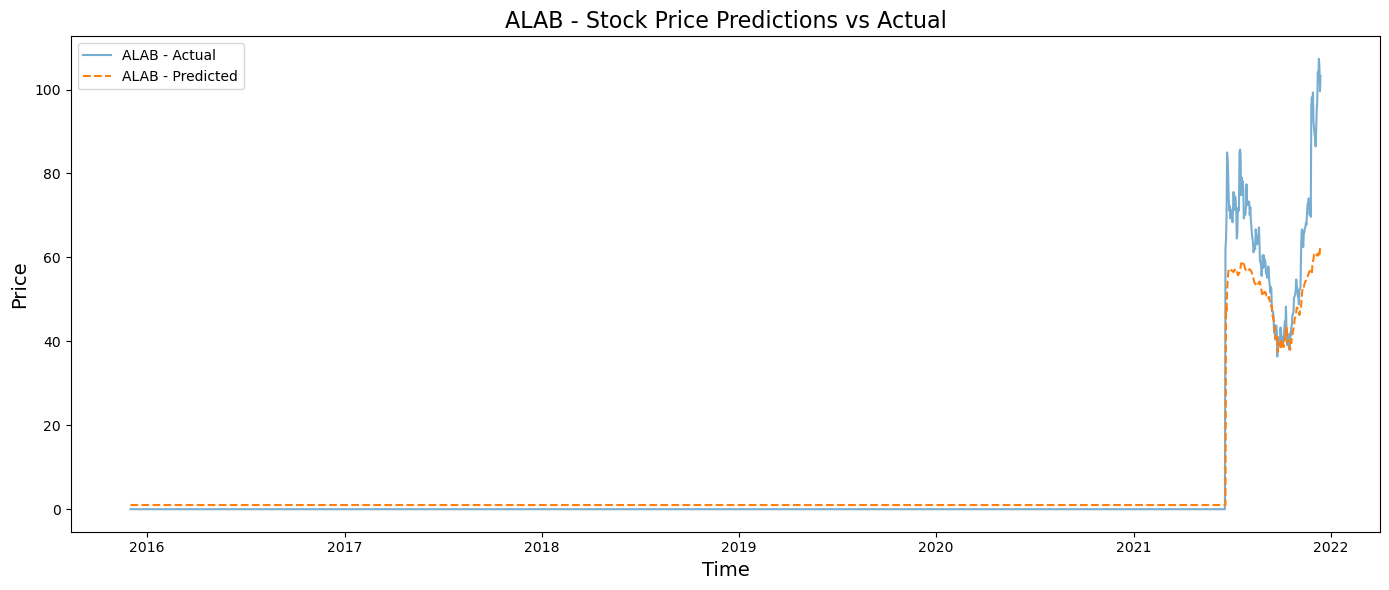

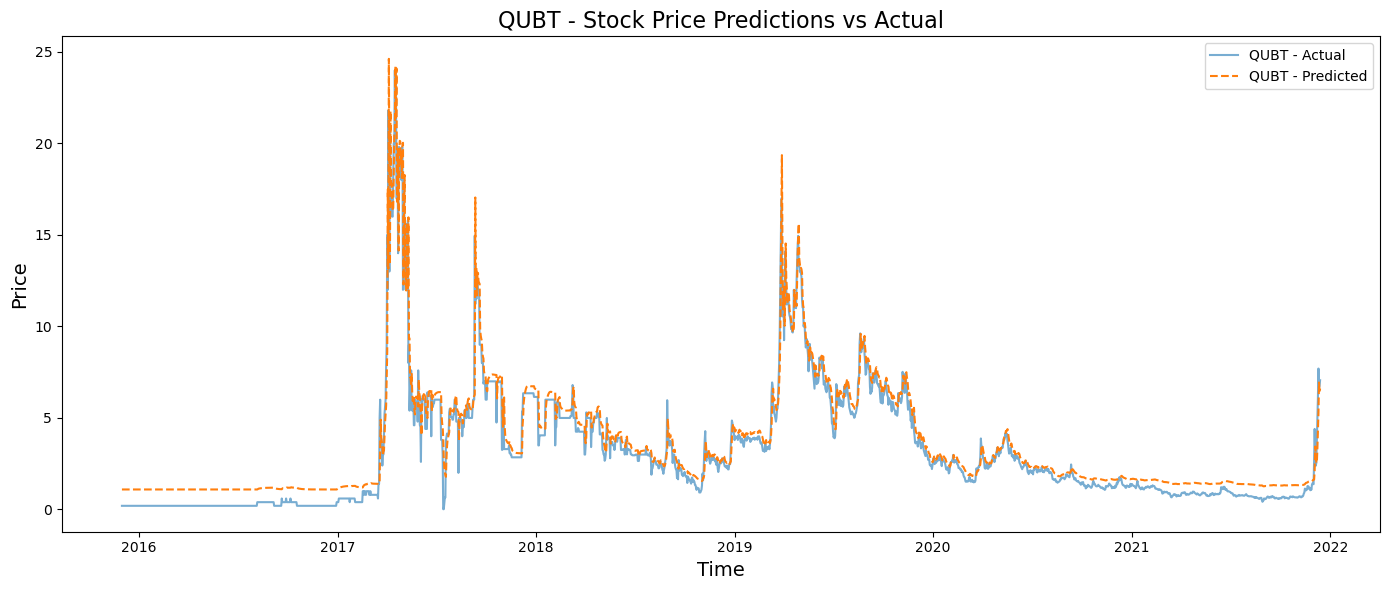

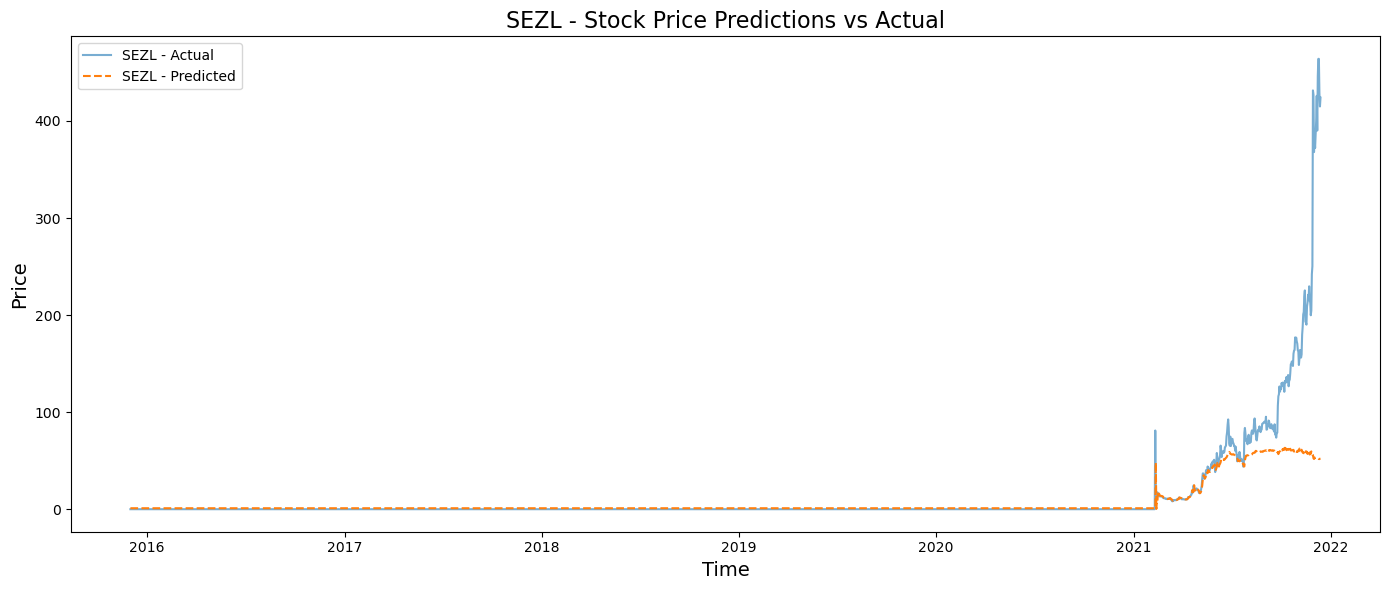

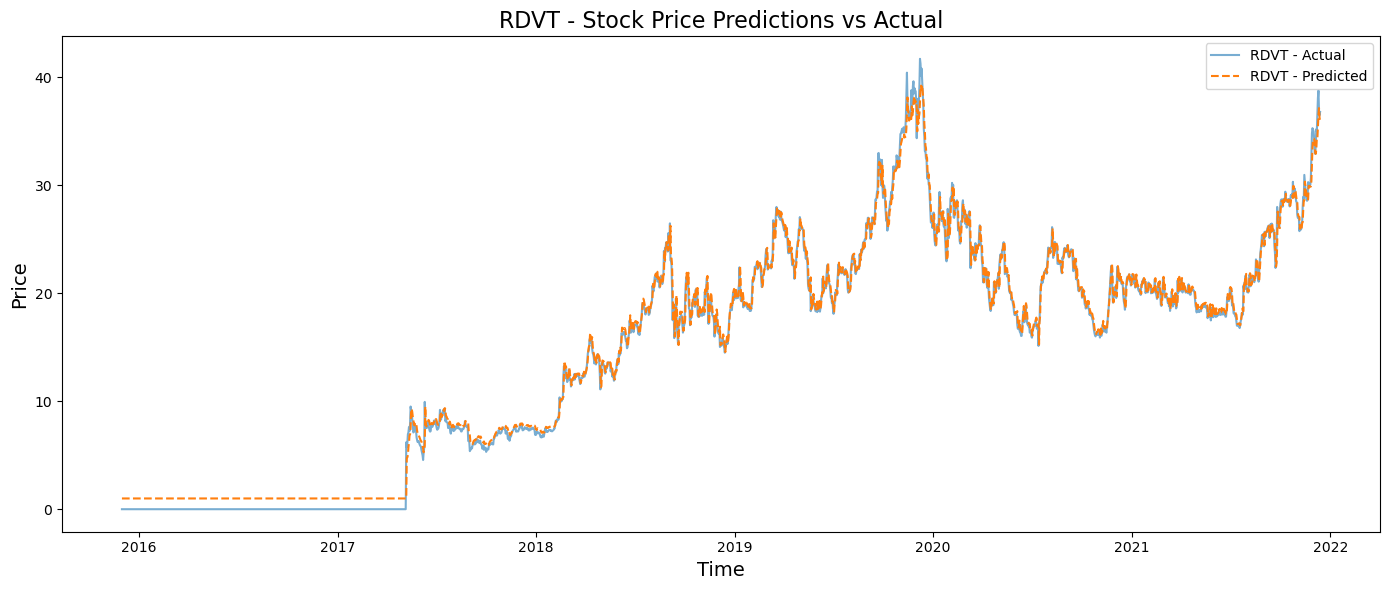

In [66]:
# Loop through each ticker to plot its data in a separate figure
for ticker in tickers:
    # Create a new figure for each ticker
    plt.figure(figsize=(14, 6))
    
    # Check if the ticker exists in the predictions dictionary
    if ticker in all_predictions:
        actual_prices = dataset[ticker].values[sequence_length:]  # Actual prices for each ticker
        predicted_prices = all_predictions[ticker]  # Predictions for each ticker
        dates = pd.date_range(start="2015-12-01", periods=len(actual_prices), freq='D')

        # Plot actual and predicted prices for each ticker
        plt.plot(dates, actual_prices, label=f'{ticker} - Actual', alpha=0.6)
        plt.plot(dates, predicted_prices, label=f'{ticker} - Predicted', linestyle='dashed')
    else:
        print(f"Warning: Predictions for {ticker} not found!")
    

    # Add labels and title for each plot
    plt.title(f'{ticker} - Stock Price Predictions vs Actual', fontsize=16)
    plt.xlabel('Time', fontsize=14)
    plt.ylabel('Price', fontsize=14)

    # Show legend
    plt.legend()
    plt.tight_layout()
    # Display the plot for the current ticker
    plt.show()


In [67]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Calculate Mean Squared Error (MSE) and Mean Absolute Error (MAE)
mse = mean_squared_error(actual_prices, predicted_prices)
mae = mean_absolute_error(actual_prices, predicted_prices)

print(f'Mean Squared Error (MSE) for {ticker}: {mse}')
print(f'Mean Absolute Error (MAE) for {ticker}: {mae}')


Mean Squared Error (MSE) for RDVT: 0.6899169949107405
Mean Absolute Error (MAE) for RDVT: 0.6498745874482759
